#### Teoría de Circuitos II - UTN.BA

# Tarea Semanal 5
#### Autor: Rodríguez Silvosa, Martín
#### Docentes: LLamedo, Mariano ; Moharos, David

### Consigna:
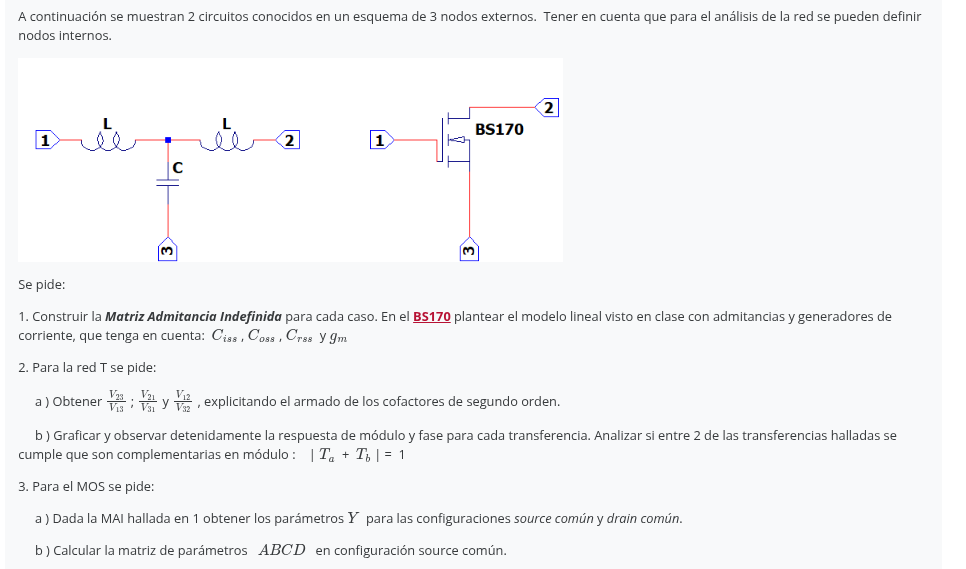

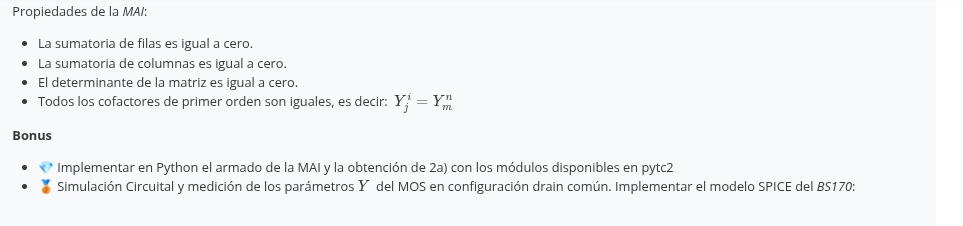

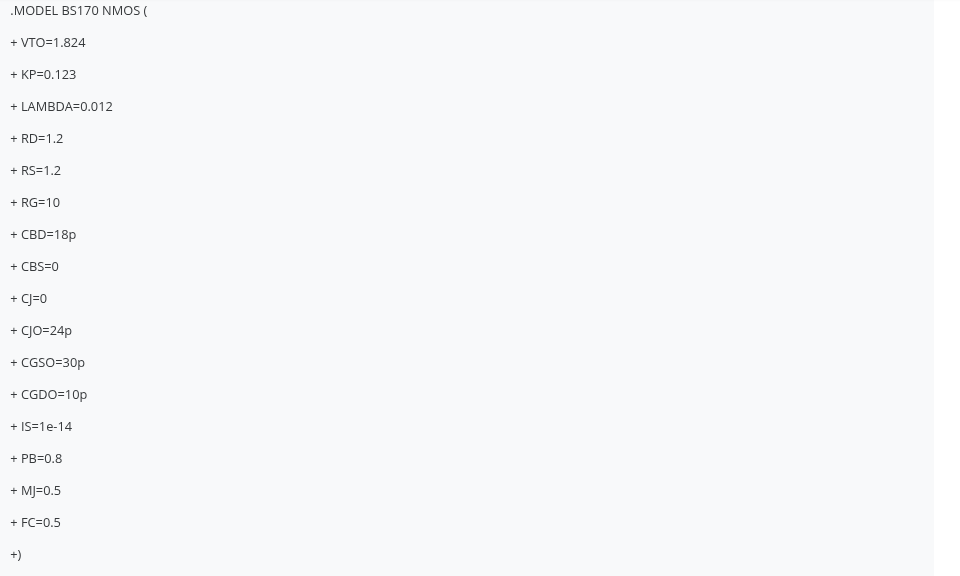

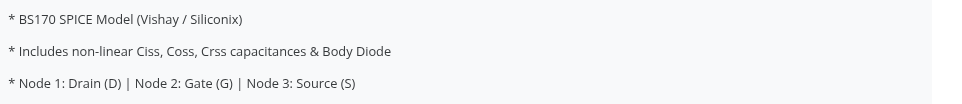

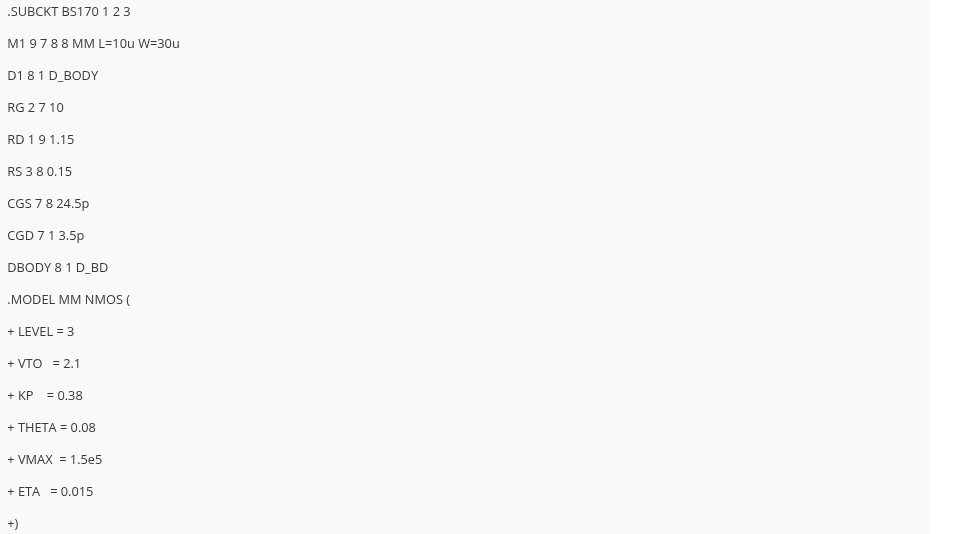

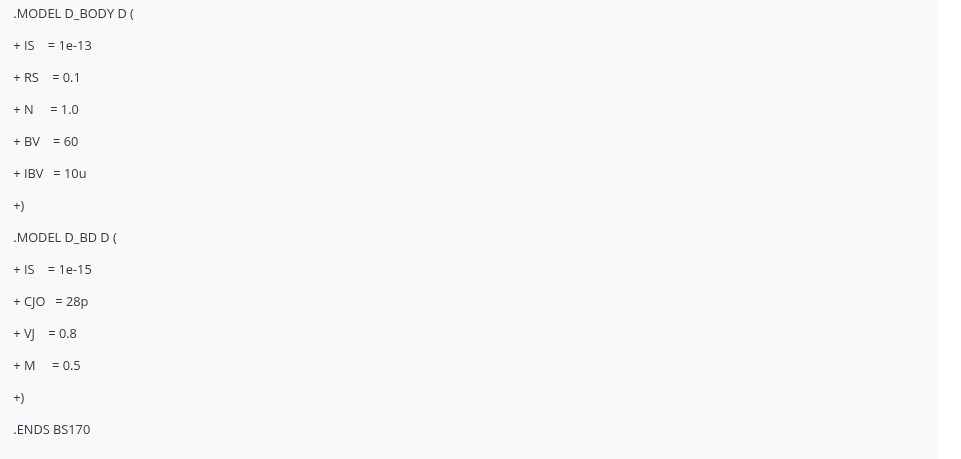

#### Librerías a usar:

In [2]:
import sympy as sp
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sig
import math

In [3]:
sp.init_printing()

# Variables simbólicas
s, L, C = sp.symbols('s L C', nonzero=True)
Y_L = 1/(s*L)
Y_C = s*C


## Red T — construcción de la MAI

La red tiene tres nodos externos y consideraremos un nodo interno X:

- $1\leftrightarrow x$: inductor \(L\)
- $x\leftrightarrow 2$: inductor \(L\)
- $x\leftrightarrow 3$: capacitor \(C\)

### Armamos la MAI de 4 nodos: diagonal principal será la sumatoria de todas las admitancias que entran al nodo

$$Nodo 1: YL$$
$$Nodo 2: YL$$
$$Nodo 3: YC$$
$$Nodo X: 2*YL + YC$$

### Por observación y partiendo que la sumatoria de cada fila y cada columna tiene que ser 0 podemos ver que:
#### Y34 será -YC
#### Y24 será -YL
#### Y14 será -YL
#### Y43 será -YC
#### Y42 será -YL
#### Y41 será -YL
#### El resto tiene que ser 0

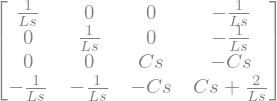

In [4]:
# Orden de los nodos: [1, 2, 3, x]
Y_T_4 = sp.Matrix([
    [Y_L, 0,   0,   -Y_L],
    [0,   Y_L, 0,   -Y_L],
    [0,   0,   Y_C, -Y_C],
    [-Y_L,-Y_L,-Y_C, 2*Y_L + Y_C]
])

Y_T_4

### Procedemos a eliminar el nodo interno creado para el resultado final:

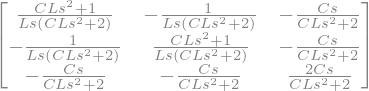

In [5]:

# Eliminación del nodo interno x:
# Y_ext = Y_ee - Y_ex * Y_xx^(-1) * Y_xe
Y_ee = Y_T_4[:3, :3]
Y_ex = Y_T_4[:3, 3]
Y_xe = Y_T_4[3, :3]
Y_xx = Y_T_4[3, 3]

Y_T = sp.simplify(Y_ee - Y_ex * Y_xe / Y_xx)

sp.simplify(Y_T)

### La MAI reducida de los tres nodos externos queda

$[
\boxed{
\mathbf Y_{MAI}=
\frac{1}{Ls(CLs^2+2)}
\begin{bmatrix}
CLs^2+1 & -1 & -CLs^2\\
-1 & CLs^2+1 & -CLs^2\\
-CLs^2 & -CLs^2 & 2CLs^2
\end{bmatrix}
}
$]

#### donde la relación entre corrientes y tensiones es

$[
\mathbf I=\mathbf Y_{MAI}\,\mathbf V
$]

## Corroboración:
#### Comprobaremos que los resultados son válidos y cumplen que la sumatoria de cada fila y cada columna es 0 y que el determinante es 0:

In [6]:

# Comprobaciones estructurales de la MAI
print("Suma de filas:")
display(sp.simplify(Y_T * sp.ones(3,1)))

print("Suma de columnas:")
display(sp.simplify(sp.ones(1,3) * Y_T))

print("det(Y_T) =", sp.factor(Y_T.det()))

Suma de filas:


Suma de columnas:


det(Y_T) = 0


## 2 Transferencias de la red T

$[
\frac{V_{23}}{V_{13}},\qquad
\frac{V_{21}}{V_{31}},\qquad
\frac{V_{12}}{V_{32}}
$]

- $(V_{23}/V_{13}$): nodo 3 como referencia y nodo 2 abierto ($(I_2=0$)).
- $(V_{21}/V_{31}$): nodo 1 como referencia y nodo 2 abierto ($(I_2=0$)).
- $(V_{12}/V_{32}$): nodo 2 como referencia y nodo 1 abierto ($(I_1=0$)).

#### Trabajaremos con matrices $(2\times2$), con cofactores de segundo orden.

### Caso A: $(V_{23}/V_{13}$)

#### Con $(V_3=0$), queda:

$[
\begin{bmatrix}I_1\\I_2\end{bmatrix}
=
\begin{bmatrix}
Y_{11}&Y_{12}\\
Y_{21}&Y_{22}
\end{bmatrix}
\begin{bmatrix}V_1\\V_2\end{bmatrix},
\qquad I_2=0
$]

#### Por consiguiente nos queda:

$[
V_1=\frac{Y_{22}}{\Delta}I_1,\qquad
V_2=-\frac{Y_{21}}{\Delta}I_1
$]

#### con:

$[
\Delta=Y_{11}Y_{22}-Y_{12}Y_{21}
$]

#### Entonces nos queda:

$[
\boxed{\frac{V_{23}}{V_{13}}
=\frac{V_2}{V_1}
=-\frac{Y_{21}}{Y_{22}}}
$]

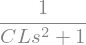

In [7]:
# Caso A referencia nodo 3 -> submatriz [1,2]
Y_A = sp.simplify(Y_T[:2, :2])

T_a = sp.factor(-Y_A[1,0] / Y_A[1,1])
T_a

### Caso B $(V_{21}/V_{31}$):

Ahora $(V_1=0$). Los nodos son $(2,3$), y el nodo de salida 2 está abierto:

$[
I_2=0
$]

#### La misma aplicación da:

$[
\boxed{
\frac{V_{21}}{V_{31}}
=
\frac{V_2}{V_3}
=
-\frac{Y_{23}}{Y_{22}}
}
$]

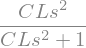

In [8]:

# Caso B referencia nodo 1 -> submatriz [2,3]
Y_B = sp.simplify(Y_T.extract([1,2], [1,2]))

T_b = sp.factor(-Y_B[0,1] / Y_B[0,0])
T_b


### Caso C $(V_{12}/V_{32}$) :

Tomamos $(V_2=0$). Los nodos activos son $(1,3$) y el nodo 1 está abierto:

$[
I_1=0
$]

#### Entonces:

$[
\boxed{
\frac{V_{12}}{V_{32}}
=
\frac{V_1}{V_3}
=
-\frac{Y_{13}}{Y_{11}}
}
$]

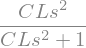

In [9]:
# Caso c: referencia nodo 2 -> submatriz [1,3]
Y_Cmat = sp.simplify(Y_T.extract([0,2], [0,2]))

T_c = sp.factor(-Y_Cmat[0,1] / Y_Cmat[0,0])
T_c


### Resultado simbólico:

#### Definiendo para simplificar el análisis que:

$[
x=s^2LC
$]

se obtiene

$[
\boxed{T_a=\frac{1}{1+x}}
$]

$[
\boxed{T_b=\frac{x}{1+x}}
$]

$[
\boxed{T_c=\frac{x}{1+x}}
$]

#### Y se corrobora que el resultado del módulo nos queda:

$[
\boxed{T_a+T_b=1}
$]

In [10]:

print("T_a =", sp.factor(T_a))
print("T_b =", sp.factor(T_b))
print("T_c =", sp.factor(T_c))
print("T_a + T_b =", sp.factor(T_a + T_b))


T_a = 1/(C*L*s**2 + 1)
T_b = C*L*s**2/(C*L*s**2 + 1)
T_c = C*L*s**2/(C*L*s**2 + 1)
T_a + T_b = 1


## Respuesta de módulo y fase

Para visualizar las respuestas usamos $(s=j\omega$). Para $(T_a$) y $(T_b$):

$[
T_a(j\omega)=\frac{1}{1-\omega^2LC},
\qquad
T_b(j\omega)=\frac{-\omega^2LC}{1-\omega^2LC}
$]

$[
\omega_0=\frac{1}{\sqrt{LC}},
\qquad
f_0=\frac{1}{2\pi\sqrt{LC}}
$]

Frecuencia característica f0 = 1.5915 MHz


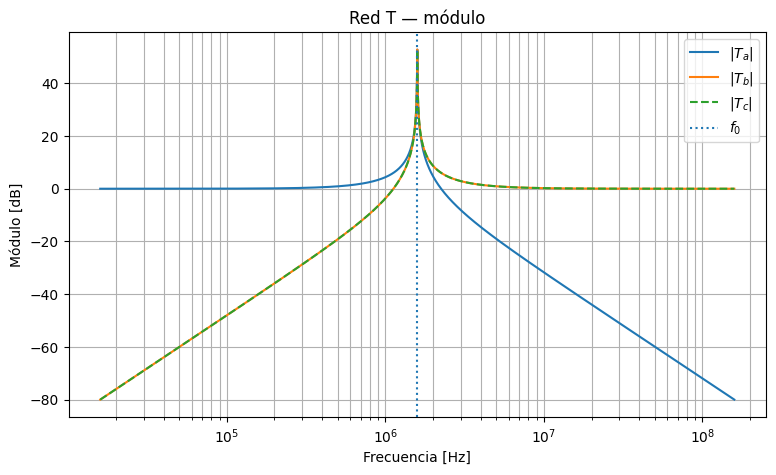

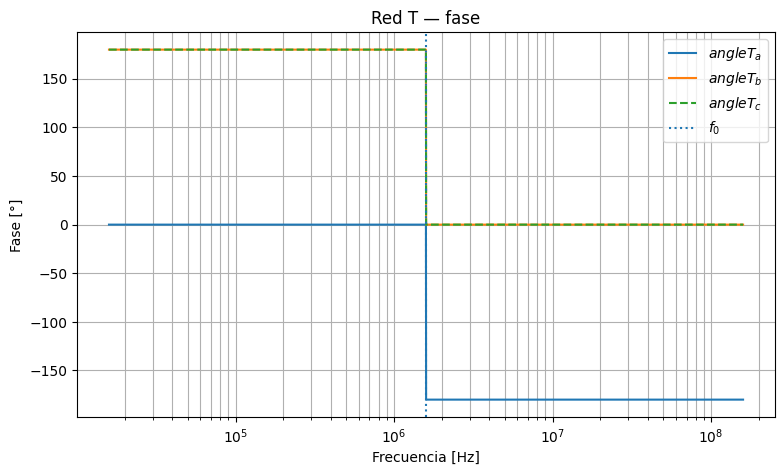

In [12]:
# Asumo valores para visualizar algo coherente.
L_num = 10e-6   # H
C_num = 1e-9    # F

f0 = 1/(2*np.pi*np.sqrt(L_num*C_num))
print(f"Frecuencia característica f0 = {f0/1e6:.4f} MHz")

f = np.logspace(np.log10(f0/100), np.log10(f0*100), 4000)
w = 2*np.pi*f
x = (1j*w)**2 * L_num * C_num

Ta_num = 1/(1+x)
Tb_num = x/(1+x)
Tc_num = Tb_num

phase = lambda z: np.unwrap(np.angle(z))*180/np.pi

plt.figure(figsize=(9,5))
plt.semilogx(f, 20*np.log10(np.abs(Ta_num)), label=r'$|T_a|$')
plt.semilogx(f, 20*np.log10(np.abs(Tb_num)), label=r'$|T_b|$')
plt.semilogx(f, 20*np.log10(np.abs(Tc_num)), '--', label=r'$|T_c|$')
plt.axvline(f0, linestyle=':', label=r'$f_0$')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.title('Red T — módulo')
plt.grid(True, which='both')
plt.legend()
plt.show()

plt.figure(figsize=(9,5))
plt.semilogx(f, phase(Ta_num), label=r'$angle T_a$')
plt.semilogx(f, phase(Tb_num), label=r'$angle T_b$')
plt.semilogx(f, phase(Tc_num), '--', label=r'$angle T_c$')
plt.axvline(f0, linestyle=':', label=r'$f_0$')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [°]')
plt.title('Red T — fase')
plt.grid(True, which='both')
plt.legend()
plt.show()

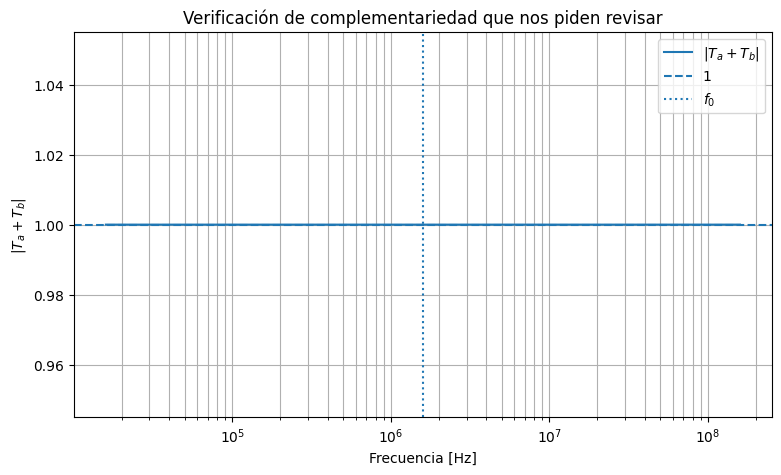

In [14]:
# Verificación numérica:
# llamémosle compl por poner
compl = np.abs(Ta_num + Tb_num)

plt.figure(figsize=(9,5))
plt.semilogx(f, compl, label=r'$|T_a+T_b|$')
plt.axhline(1, linestyle='--', label='1')
plt.axvline(f0, linestyle=':', label=r'$f_0$')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel(r'$|T_a+T_b|$')
plt.title('Verificación de complementariedad que nos piden revisar')
plt.grid(True, which='both')
plt.legend()
plt.show()

## 3 BS170 

Para el transistor usamos los tres nodos externos:

- nodo 1: Gate
- nodo 2: Drain
- nodo 3: Source

El modelo tiene:

$[
C_{gd}=C_{rss}
$]

$[
C_{gs}=C_{iss}-C_{rss}
$]

$[
C_{ds}=C_{oss}-C_{rss}.
$]

Ponemos el generador de corriente controlado:

$[
i_{gm}=g_m v_{gs}=g_m(v_1-v_3)
$]

orientado de drain hacia source.

Las admitancias capacitivas son

$[
Y_{gd}=sC_{gd},\qquad
Y_{gs}=sC_{gs},\qquad
Y_{ds}=sC_{ds}
$]

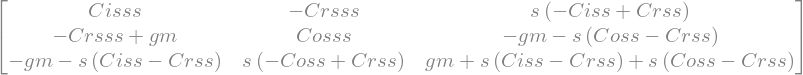

In [15]:
# Parámetros simbólicos del MOS
Ciss, Coss, Crss, gm = sp.symbols('Ciss Coss Crss gm', nonzero=True)

Cgd = Crss
Cgs = Ciss - Crss
Cds = Coss - Crss

Ygd = s*Cgd
Ygs = s*Cgs
Yds = s*Cds

# MAI, nodos [G,D,S]
Ycap = sp.Matrix([
    [Ygd + Ygs, -Ygd,       -Ygs],
    [-Ygd,      Ygd + Yds,  -Yds],
    [-Ygs,      -Yds,       Ygs + Yds]
])

# Stamp del gm: corriente D->S = gm*(vG-vS)
Ygm = sp.Matrix([
    [0,   0,   0],
    [gm,  0,  -gm],
    [-gm, 0,   gm]
])

Y_MOS = sp.simplify(Ycap + Ygm)

Y_MOS

### La MAI del transistor MOS nos queda:

$[
\boxed{
\mathbf Y_{MOS}=
\begin{bmatrix}
s(C_{gs}+C_{gd})&
-sC_{gd}&
-sC_{gs}\\[2mm]
g_m-sC_{gd}&
s(C_{gd}+C_{ds})&
-g_m-sC_{ds}\\[2mm]
-g_m-sC_{gs}&
-sC_{ds}&
g_m+s(C_{gs}+C_{ds})
\end{bmatrix}
}
$]

#### reemplazando las relaciones pedidas:

$[
C_{gd}=C_{rss},\quad
C_{gs}=C_{iss}-C_{rss},\quad
C_{ds}=C_{oss}-C_{rss}.
$]

### Verificación rápida:

In [16]:
print("Suma de filas:")
display(sp.simplify(Y_MOS * sp.ones(3,1)))

print("Suma de columnas:")
display(sp.simplify(sp.ones(1,3) * Y_MOS))

Suma de filas:


Suma de columnas:


##  Parámetros $(Y$) :

### Source común

Tomamos el source como terminal común:

$[
v_S=0.
$]

Los voltajes de puerto son:

$[
v_1=v_{GS},\qquad v_2=v_{DS}
$]

Y las corrientes de puerto son:

$[
i_1=i_G,\qquad i_2=i_D.
$]

Tomamos la submatriz correspondiente a Gate y Drain:

$[
\boxed{
\mathbf Y_{SC}
=
\begin{bmatrix}
Y_{GG}&Y_{GD}\\
Y_{DG}&Y_{DD}
\end{bmatrix}
}
$]

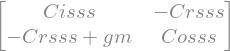

In [17]:
# Source común: S como referencia -> nodos [G,D]
Y_SC = sp.simplify(Y_MOS.extract([0,1],[0,1]))

Y_SC

### Drain común

Tomamos el drain como terminal común:

$[
v_D=0
$]

Los voltajes son:

$[
v_1=v_{GD},\qquad v_2=v_{SD}
$]

Y las corrientes:

$[
i_1=i_G,\qquad i_2=i_S
$]

Entonces nos queda:

$[
\boxed{
\mathbf Y_{DC}
=
\begin{bmatrix}
Y_{GG}&Y_{GS}\\
Y_{SG}&Y_{SS}
\end{bmatrix}
}
$]

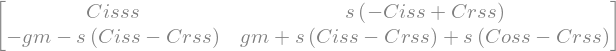

In [18]:
# Drain común: D como referencia -> nodos [G,S]
Y_DC = sp.simplify(Y_MOS.extract([0,2],[0,2]))

Y_DC


## Matriz ABCD — source común

Recordemos:

$[
\begin{bmatrix}
V_1\\I_1
\end{bmatrix}
=
\begin{bmatrix}
A&B\\C&D
\end{bmatrix}
\begin{bmatrix}
V_2\\-I_2
\end{bmatrix}
$]

Partimos de:

$[
\begin{aligned}
I_1&=Y_{11}V_1+Y_{12}V_2,\\
I_2&=Y_{21}V_1+Y_{22}V_2.
\end{aligned}
$]

Despejando $(V_1$) e $(I_1$):

$[
\boxed{
A=-\frac{Y_{22}}{Y_{21}}
}
$]

$[
\boxed{
B=-\frac{1}{Y_{21}}
}
$]

$[
\boxed{
C=Y_{12}-\frac{Y_{11}Y_{22}}{Y_{21}}
=\frac{Y_{12}Y_{21}-Y_{11}Y_{22}}{Y_{21}}
}
$]

$[
\boxed{
D=-\frac{Y_{11}}{Y_{21}}
}
$]

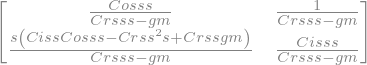

In [19]:
y11, y12 = Y_SC[0,0], Y_SC[0,1]
y21, y22 = Y_SC[1,0], Y_SC[1,1]

A = sp.factor(-y22/y21)
B = sp.factor(-1/y21)
C_abcd = sp.factor(y12 - y11*y22/y21)
D = sp.factor(-y11/y21)

ABCD_SC = sp.Matrix([
    [A, B],
    [C_abcd, D]
])

ABCD_SC

A =


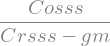

B =


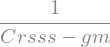

C =


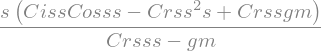

D =


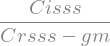

In [20]:
for name, expr in zip(["A","B","C","D"], [A,B,C_abcd,D]):
    print(name, "=")
    display(sp.factor(expr))